In [1]:
pip install pandas numpy pymysql sqlalchemy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

### Connecting mysql to python

In [7]:
username = "root"
password = "1234567890"
host = "localhost"
port = "3306"
database = "retail_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("Connection Successful")

Connection Successful


### Load Data

In [8]:
orders = pd.read_sql("select * from orders", engine)
print (orders.head())

   order_id  customer_id  order_status  order_date required_date shipped_date  \
0         1          259             4  2016-01-01    2016-01-03   2016-01-03   
1         2         1212             4  2016-01-01    2016-01-04   2016-01-03   
2         3          523             4  2016-01-02    2016-01-05   2016-01-03   
3         4          175             4  2016-01-03    2016-01-04   2016-01-05   
4         5         1324             4  2016-01-03    2016-01-06   2016-01-06   

   store_id  staff_id order_status_label  
0         1         2          Completed  
1         2         6          Completed  
2         2         7          Completed  
3         1         3          Completed  
4         2         6          Completed  


In [30]:
order_items = pd.read_sql("SELECT * FROM order_items", engine)
products = pd.read_sql("SELECT * FROM product", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
stores = pd.read_sql("SELECT * FROM stores", engine)
staff = pd.read_sql("SELECT * FROM staff", engine)
brands = pd.read_sql("SELECT * FROM brands",engine)
categories = pd.read_sql("SELECT * FROM categories",engine)

In [12]:
products.head()

,Product_id,Product_Name,Brand_Id,Category_Id,Model_Year,List_Price
0,1,Trek 820 - 2016,9,6,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,5,6,2016,749.99
2,3,Surly Wednesday Frameset - 2016,8,6,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,9,6,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,3,6,2016,1320.99


In [14]:
customers.head()

,customer_id,first_name,last_name,phone,email,street,city,state,zip_code
0,1,Debra,Burks,Not Available,debra.burks@yahoo.com,9273 Thorne Ave.,Orchard Park,NY,14127
1,2,Kasha,Todd,Not Available,kasha.todd@yahoo.com,910 Vine Street,Campbell,CA,95008
2,3,Tameka,Fisher,Not Available,tameka.fisher@aol.com,769C Honey Creek St.,Redondo Beach,CA,90278
3,4,Daryl,Spence,Not Available,daryl.spence@aol.com,988 Pearl Lane,Uniondale,NY,11553
4,5,Charolette,Rice,(916) 381-6003,charolette.rice@msn.com,107 River Dr.,Sacramento,CA,95820


In [15]:
stores.head()

,store_id,store_name,phone,email,street,city,state,zip_code
0,1,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060
1,2,Baldwin Bikes,(516) 379-8888,baldwin@bikes.shop,4200 Chestnut Lane,Baldwin,NY,11432
2,3,Rowlett Bikes,(972) 530-5555,rowlett@bikes.shop,8000 Fairway Avenue,Rowlett,TX,75088


In [24]:
brands.head()

,brand_id,brand_name
0,1,Electra
1,2,Haro
2,3,Heller
3,4,Pure Cycles
4,5,Ritchey


In [32]:
orders.columns = orders.columns.str.lower()
order_items.columns = order_items.columns.str.lower()
products.columns = products.columns.str.lower()
customers.columns = customers.columns.str.lower()
stores.columns = stores.columns.str.lower()
brands.columns = brands.columns.str.lower()
categories.columns = categories.columns.str.lower()

### Merge Tables

In [33]:
sales = orders.merge(order_items, on="order_id")

sales = sales.merge(products, on="product_id")

sales = sales.merge(customers, on="customer_id")

sales = sales.merge(stores,on="store_id")

sales = sales.merge(brands,on="brand_id")

sales = sales.merge(categories,on="category_id")
sales.head()

,order_id,customer_id,order_status,order_date,required_date,shipped_date,store_id,staff_id,order_status_label,item_id,...,zip_code_x,store_name,phone_y,email_y,street_y,city_y,state_y,zip_code_y,brand_name,category_name
0,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,1,...,94566,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,Electra,Cruisers Bicycles
1,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,2,...,94566,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,Trek,Mountain Bikes
2,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,3,...,94566,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,Surly,Cyclocross Bicycles
3,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,4,...,94566,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,Electra,Cruisers Bicycles
4,1,259,4,2016-01-01,2016-01-03,2016-01-03,1,2,Completed,5,...,94566,Santa Cruz Bikes,(831) 476-4321,santacruz@bikes.shop,3700 Portola Drive,Santa Cruz,CA,95060,Trek,Mountain Bikes


### Revenue By Stores

In [34]:
store_revenue = sales.groupby("store_name")["net_revenue"].sum().reset_index()

store_revenue = store_revenue.sort_values(
    by="net_revenue",
    ascending=False
)

print(store_revenue)

         store_name  net_revenue
0     Baldwin Bikes   5215746.64
2  Santa Cruz Bikes   1605821.56
1     Rowlett Bikes    867541.51


### Revenue By Brand

In [35]:
brand_revenue = sales.groupby("brand_name")["net_revenue"].sum()

print(brand_revenue)

brand_name
Electra         1205318.10
Haro             185384.19
Heller           171458.93
Pure Cycles      149476.34
Ritchey           78898.82
Strider            4320.45
Sun Bicycles     341994.16
Surly            949506.31
Trek            4602752.41
Name: net_revenue, dtype: float64


### Monthly Sales Trend

In [36]:
sales["order_date"] = pd.to_datetime(sales["order_date"])

sales["year_month"] = sales["order_date"].dt.to_period("M")

monthly_sales = sales.groupby("year_month")["net_revenue"].sum()

print(monthly_sales)

year_month
2016-01    215146.23
2016-02    156112.11
2016-03    180600.13
2016-04    167143.90
2016-05    205269.82
2016-06    210561.95
2016-07    199556.61
2016-08    225657.16
2016-09    273091.37
2016-10    212077.86
2016-11    182329.24
2016-12    199829.79
2017-01    285616.26
2017-02    312923.47
2017-03    308911.60
2017-04    227290.63
2017-05    268232.99
2017-06    378865.34
2017-07    229995.14
2017-08    290553.17
2017-09    293405.03
2017-10    310328.02
2017-11    281577.65
2017-12    259505.76
2018-01    381429.86
2018-02    200657.90
2018-03    363990.72
2018-04    817921.28
2018-06       188.99
2018-07     11337.89
2018-08      8377.80
2018-09      8963.96
2018-10      3781.12
2018-11     11362.00
2018-12      6516.96
Freq: M, Name: net_revenue, dtype: float64


### Time Series Trend Insights

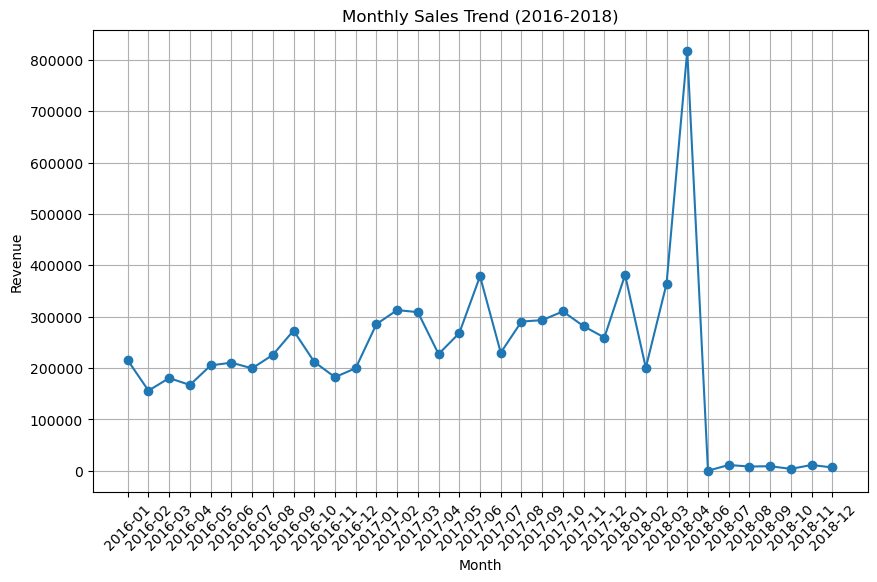

In [39]:
import matplotlib.pyplot as plt
# Convert order_date to datetime
sales['order_date'] = pd.to_datetime(sales['order_date'])

# Create year-month column
sales['year_month'] = sales['order_date'].dt.to_period('M')

# Monthly revenue
monthly_sales = sales.groupby('year_month')['net_revenue'].sum().reset_index()

# Convert to string for plotting
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# Plot
plt.figure(figsize=(10,6))

plt.plot(
    monthly_sales['year_month'],
    monthly_sales['net_revenue'],
    marker='o'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend (2016-2018)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Customer Lifetime Value

In [40]:
customer_ltv = sales.groupby(
    ["customer_id", "first_name", "last_name"]
).agg({
    "order_id": "nunique",
    "net_revenue": "sum"
}).reset_index()

customer_ltv.columns = [
    "customer_id",
    "first_name",
    "last_name",
    "total_orders",
    "lifetime_value"
]

print(customer_ltv.head())

   customer_id  first_name last_name  total_orders  lifetime_value
0            1       Debra     Burks             3        27888.17
1            2       Kasha      Todd             3        19329.07
2            3      Tameka    Fisher             3        24051.51
3            4       Daryl    Spence             3        21150.88
4            5  Charolette      Rice             3        17520.28


### Moving Average Trend

In [45]:
print(sales.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_date',
       'required_date', 'shipped_date', 'store_id', 'staff_id',
       'order_status_label', 'item_id', 'product_id', 'quantity',
       'list_price_x', 'discount', 'net_revenue', 'product_name', 'brand_id',
       'category_id', 'model_year', 'list_price_y', 'first_name', 'last_name',
       'phone_x', 'email_x', 'street_x', 'city_x', 'state_x', 'zip_code_x',
       'store_name', 'phone_y', 'email_y', 'street_y', 'city_y', 'state_y',
       'zip_code_y', 'brand_name', 'category_name', 'year_month'],
      dtype='object')


In [46]:
sales['net_revenue'] = (
    sales['net_revenue']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

sales['net_revenue'] = pd.to_numeric(
    sales['net_revenue'],
    errors='coerce'
)

In [47]:
print(sales['net_revenue'].dtype)

float64


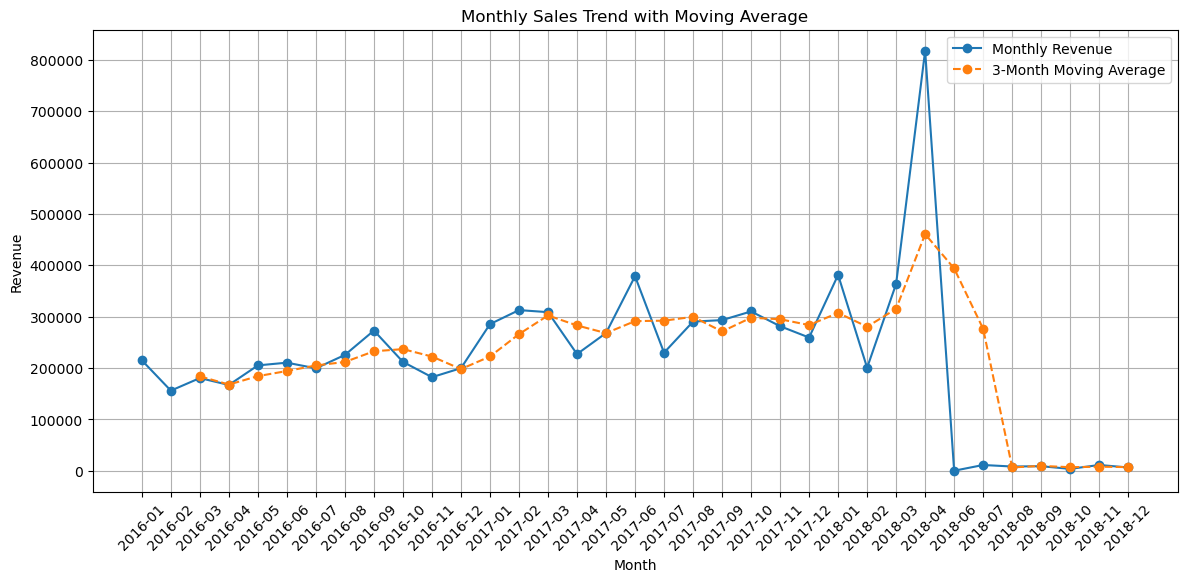

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert revenue to numeric
sales['net_revenue'] = (
    sales['net_revenue']
    .astype(str)
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

sales['net_revenue'] = pd.to_numeric(
    sales['net_revenue'],
    errors='coerce'
)

# Convert order date
sales['order_date'] = pd.to_datetime(sales['order_date'])

# Create year-month
sales['year_month'] = sales['order_date'].dt.to_period('M')

# Monthly revenue
monthly_sales = (
    sales.groupby('year_month')['net_revenue']
    .sum()
    .reset_index()
)

# Convert period to string
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# 3-Month Moving Average
monthly_sales['moving_avg'] = (
    monthly_sales['net_revenue']
    .rolling(window=3)
    .mean()
)

# Plot
plt.figure(figsize=(14,6))

# Actual Sales
plt.plot(
    monthly_sales['year_month'],
    monthly_sales['net_revenue'],
    marker='o',
    label='Monthly Revenue'
)

# Moving Average
plt.plot(
    monthly_sales['year_month'],
    monthly_sales['moving_avg'],
    marker='o',
    linestyle='--',
    label='3-Month Moving Average'
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend with Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.legend()

plt.grid(True)

plt.show()

### Customer Segmentation - Clustering

In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features

segmentation = customer_ltv[
    ["total_orders", "lifetime_value"]
]

# Scale data

scaler = StandardScaler()

scaled_data = scaler.fit_transform(segmentation)

# KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

customer_ltv["segment"] = kmeans.fit_predict(
    scaled_data
)

print(customer_ltv.head())

   customer_id  first_name last_name  total_orders  lifetime_value  segment
0            1       Debra     Burks             3        27888.17        1
1            2       Kasha      Todd             3        19329.07        1
2            3      Tameka    Fisher             3        24051.51        1
3            4       Daryl    Spence             3        21150.88        1
4            5  Charolette      Rice             3        17520.28        1


Segment 0 - High value customers, Segment 1 - Medium customers, Segment 3 - Low value customers

### Insights

In [51]:
final_insights = customer_ltv[
    [
        "customer_id",
        "total_orders",
        "lifetime_value",
        "segment"
    ]
]

print(final_insights.head())

   customer_id  total_orders  lifetime_value  segment
0            1             3        27888.17        1
1            2             3        19329.07        1
2            3             3        24051.51        1
3            4             3        21150.88        1
4            5             3        17520.28        1


In [52]:
final_insights.to_sql(
    name="customer_insights",
    con=engine,
    if_exists="replace",
    index=False
)

print("Insights table written to MySQL successfully")

Insights table written to MySQL successfully
